# Project Name: World Famous Places Analysis

### 📌 Project Overview

###### This project explores a dataset of world-famous tourist places to understand global tourism patterns.
###### The dataset includes information such as annual visitors, entry fees, UNESCO status, region, and type of attraction.
###### The analysis focuses on identifying popular destinations and understanding factors that influence tourist visits




### 🎯 Objectives

###### - To explore and understand global tourism trends using data from world-famous tourist destinations

###### - To analyze how visitor numbers vary across countries, cities, and regions

###### - To examine the impact of UNESCO World Heritage status on tourist visits

###### - To study the relationship between entry fees and annual visitors

###### - To identify the most popular types of tourist attractions

###### - To derive meaningful insights that explain what makes a tourist place highly visited

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
#Load Dataset
df = pd.read_csv("world_famous_places_2024.csv")

<br>


#### Dataset Preview

In [ ]:
#First 5 rows
df.head()

##### The dataset contains information about 30 world-famous tourist places across different countries, cities, and regions. Each record includes visitor numbers, entry fee, UNESCO status, and tourism-related attributes.
<br>


#### Dataset Structure

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Place_Name                    30 non-null     object 
 1   Country                       30 non-null     object 
 2   City                          30 non-null     object 
 3   Annual_Visitors_Millions      30 non-null     float64
 4   Type                          30 non-null     object 
 5   UNESCO_World_Heritage         30 non-null     object 
 6   Year_Built                    30 non-null     object 
 7   Entry_Fee_USD                 30 non-null     int64  
 8   Best_Visit_Month              30 non-null     object 
 9   Region                        30 non-null     object 
 10  Tourism_Revenue_Million_USD   30 non-null     int64  
 11  Average_Visit_Duration_Hours  30 non-null     float64
 12  Famous_For                    30 non-null     object 
dtypes: floa

 ##### The dataset has 13 columns. All columns have 30 non-null values, indicating a complete and well-structured dataset.
<br>

In [8]:
df.describe()

,Annual_Visitors_Millions,Entry_Fee_USD,Tourism_Revenue_Million_USD,Average_Visit_Duration_Hours
count,30.000000,30.000000,30.000000,30.000000
mean,11.331667,24.600000,593.500000,3.166667
std,12.044247,28.572473,1521.481894,2.499425
min,1.500000,0.000000,25.000000,0.500000
25%,4.775000,0.000000,61.250000,1.500000
50%,7.575000,19.000000,87.500000,2.250000
75%,12.250000,35.000000,167.500000,4.000000
max,50.000000,109.000000,6800.000000,10.000000


#### Missing Values Check

In [9]:
df.isnull().sum()

Place_Name                      0
Country                         0
City                            0
Annual_Visitors_Millions        0
Type                            0
UNESCO_World_Heritage           0
Year_Built                      0
Entry_Fee_USD                   0
Best_Visit_Month                0
Region                          0
Tourism_Revenue_Million_USD     0
Average_Visit_Duration_Hours    0
Famous_For                      0
dtype: int64

##### There are no missing values in the dataset, so no data cleaning or imputation is required before analysis.
<br>

In [10]:
print("First 5 rows:\n", df.head())
print("\nData Info:\n")
df.info()
print("\nMissing Values:\n", df.isnull().sum())
print("\nSummary Statistics:\n", df.describe(include='all'))

First 5 rows:
             Place_Name        Country              City  \
0         Eiffel Tower         France             Paris   
1         Times Square  United States     New York City   
2        Louvre Museum         France             Paris   
3  Great Wall of China          China  Beijing/Multiple   
4            Taj Mahal          India              Agra   

   Annual_Visitors_Millions                Type UNESCO_World_Heritage  \
0                       7.0      Monument/Tower                    No   
1                      50.0      Urban Landmark                    No   
2                       8.7              Museum                   Yes   
3                      10.0   Historic Monument                   Yes   
4                       7.5  Monument/Mausoleum                   Yes   

         Year_Built  Entry_Fee_USD   Best_Visit_Month          Region  \
0              1889             35  May-June/Sept-Oct  Western Europe   
1              1904              0  Apr-June/


Value Counts for Country:
 Country
United States           10
France                   4
United Kingdom           3
China                    2
Italy                    2
India                    1
Australia                1
Peru                     1
Spain                    1
Cambodia                 1
Egypt                    1
Greece                   1
United Arab Emirates     1
Brazil                   1
Name: count, dtype: int64


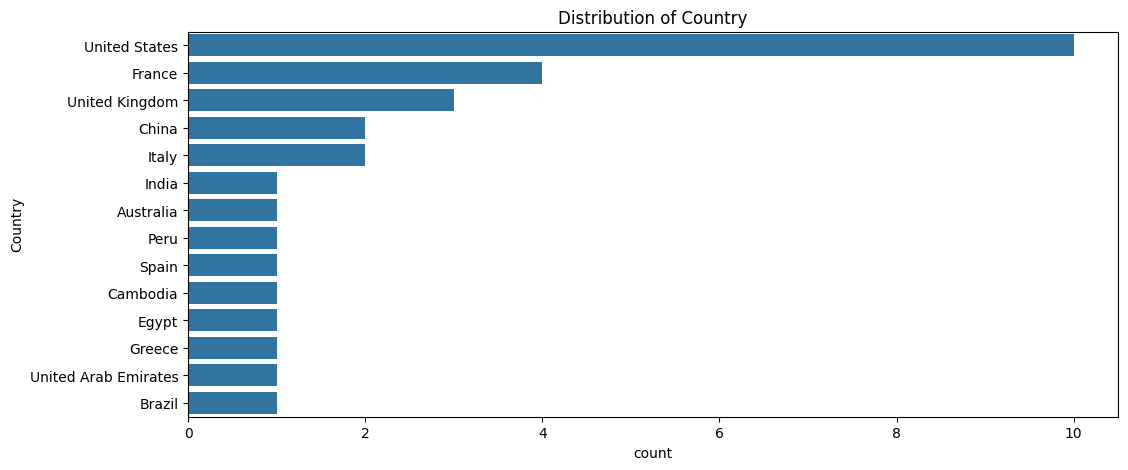


Value Counts for City:
 City
New York City       4
Paris               3
London              3
Agra                1
Rome                1
Sydney              1
Beijing/Multiple    1
Cusco Region        1
Beijing             1
Las Vegas           1
Siem Reap           1
Washington D.C.     1
Barcelona           1
Anaheim             1
San Francisco       1
Orlando             1
Arizona             1
Pisa                1
Cairo               1
Versailles          1
Athens              1
Dubai               1
Rio de Janeiro      1
Name: count, dtype: int64


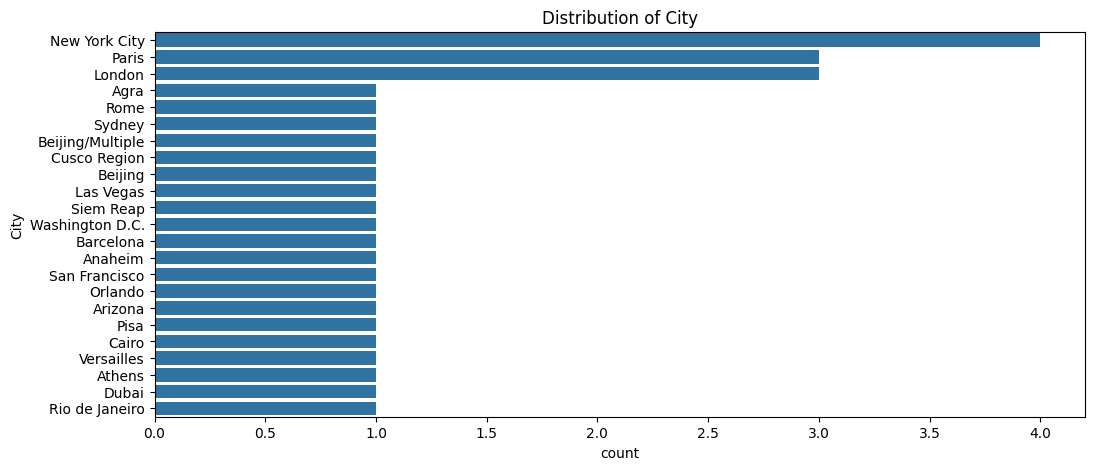


Value Counts for Type:
 Type
Historic Monument         3
Cathedral                 2
Historic Palace           2
Archaeological Site       2
Monument/Statue           2
Bridge                    2
Theme Park                2
Skyscraper                2
Monument/Tower            1
Monument/Mausoleum        1
Museum                    1
Urban Landmark            1
Cultural Building         1
Entertainment District    1
Park                      1
Temple Complex            1
Monument/Memorial         1
Natural Wonder            1
Historic Tower            1
Clock Tower               1
Palace                    1
Name: count, dtype: int64


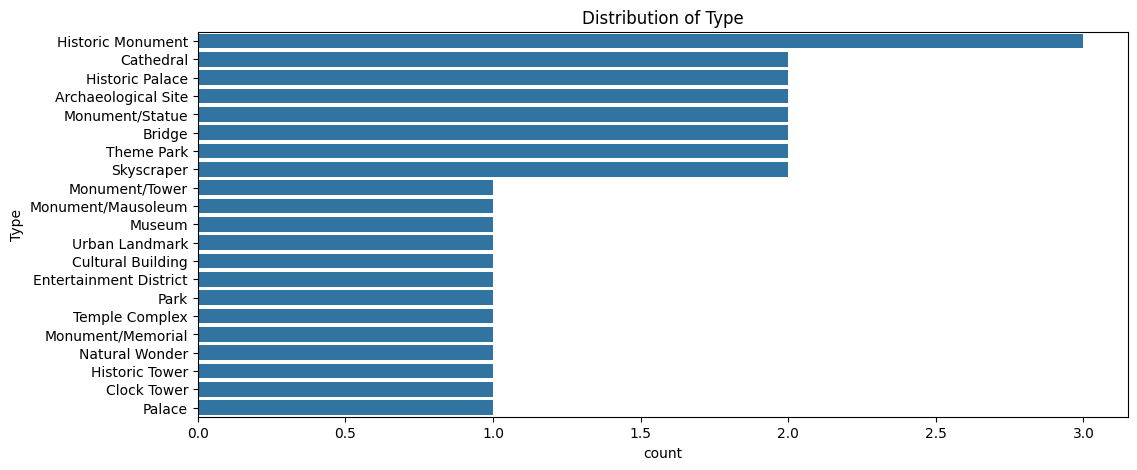


Value Counts for UNESCO_World_Heritage:
 UNESCO_World_Heritage
Yes    17
No     13
Name: count, dtype: int64


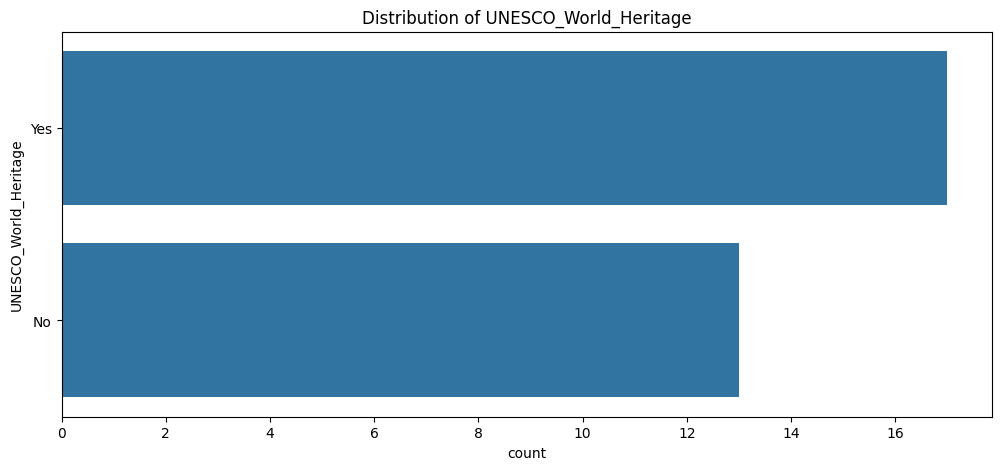


Value Counts for Best_Visit_Month:
 Best_Visit_Month
Apr-May/Sept-Oct      5
Apr-June/Sept-Oct     5
May-Sept              4
Sept-Nov              2
Oct-March             2
March-May/Sept-Nov    2
Apr-June/Sept-Nov     2
Apr-Oct               1
May-June/Sept-Oct     1
Nov-Feb               1
Apr-May/Sept-Nov      1
Jan-May/Sept-Dec      1
Oct-Apr               1
Nov-March             1
June-Sept             1
Name: count, dtype: int64


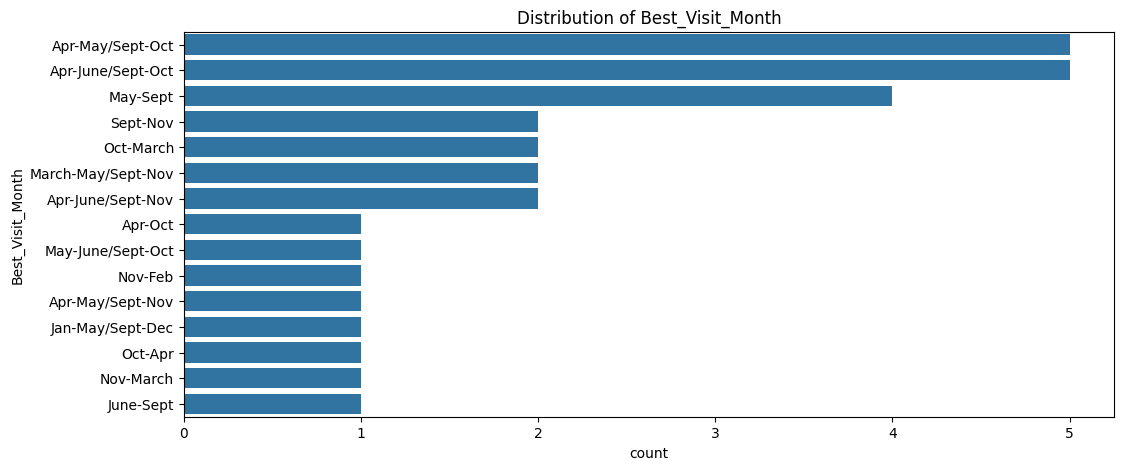


Value Counts for Region:
 Region
North America      10
Western Europe      7
Southern Europe     4
East Asia           2
South America       2
South Asia          1
Oceania             1
Southeast Asia      1
North Africa        1
Middle East         1
Name: count, dtype: int64


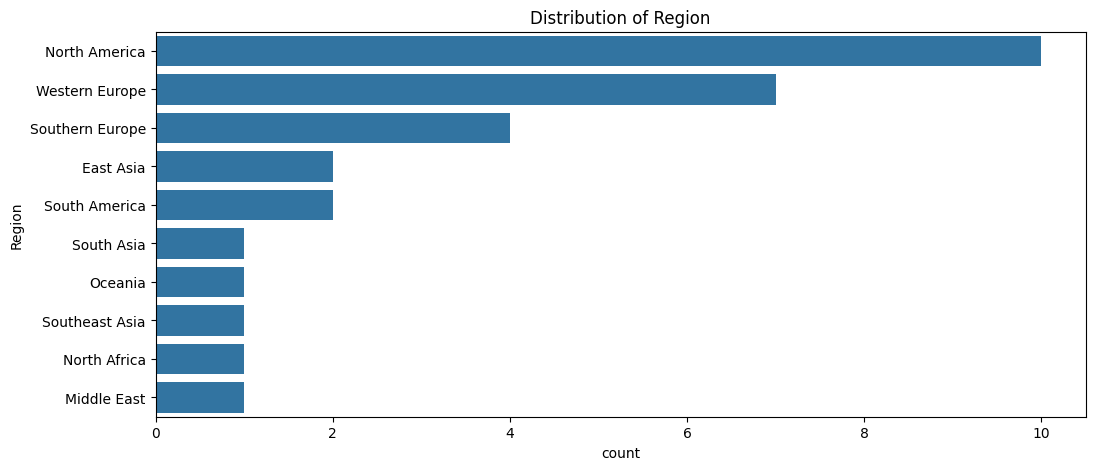

In [11]:
categorical_cols = ['Country', 'City', 'Type', 'UNESCO_World_Heritage', 'Best_Visit_Month', 'Region']

for col in categorical_cols:
    print(f"\nValue Counts for {col}:\n", df[col].value_counts())

    # Plot
    plt.figure(figsize=(12,5))
    sns.countplot(data=df, y=col, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.show()

#### Country Distribution

##### Insight:

###### - The United States has the highest number of famous tourist places in the dataset.
###### - European countries like France and the UK also contribute significantly to global tourism.

#### City Distribution

##### Insight:

###### - New York City appears most frequently, indicating it as a major global tourist hub.
###### - Cities like Paris and London also host multiple iconic attractions.

#### Attraction Type Distribution

##### Insight:

###### - Historic monuments form the largest group, followed by museums, theme parks, and bridges. This shows that cultural and historical attractions dominate global tourism.

#### UNESCO World Heritage Distribution

##### Insight:

###### - More than half of the tourist places are UNESCO World Heritage sites, highlighting the importance of cultural preservation in global tourism.

####  Region Distribution

##### Insight:

###### - North America and Western Europe dominate the dataset.
###### - Other regions such as South Asia, Africa, and Southeast Asia have fewer famous places listed, indicating potential growth areas.
<br>

#### Numerical Feature Distributions

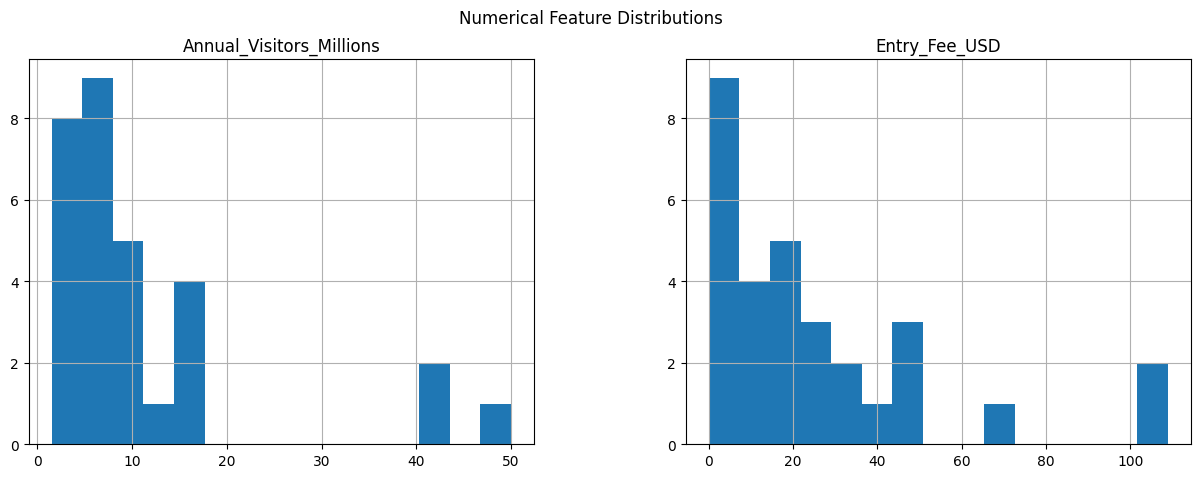

In [12]:
numerical_cols = ['Annual_Visitors_Millions', 'Year_Built', 'Entry_Fee_USD']

# Histograms
df[numerical_cols].hist(bins=15, figsize=(15,5))
plt.suptitle("Numerical Feature Distributions")
plt.show()

##### - Annual visitor counts are right-skewed, with a few very popular locations.
##### - Entry fees show high variation, from free attractions to premium-priced sites.
<br>

#### Annual Visitors Distribution

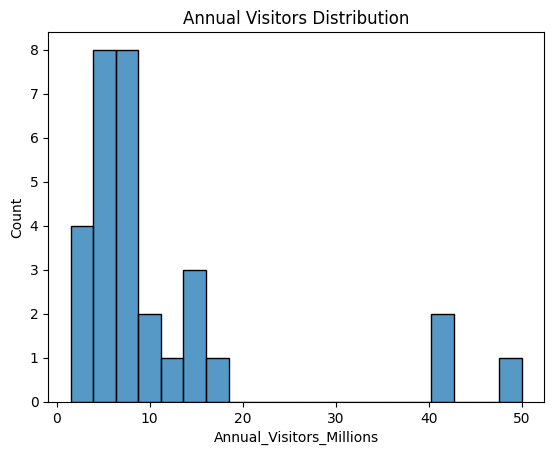

In [13]:
plt.figure()
sns.histplot(df['Annual_Visitors_Millions'], bins=20)
plt.title("Annual Visitors Distribution")
plt.show()

##### Most tourist places receive less than 15 million visitors annually, while a few major attractions act as outliers with extremely high footfall.
<br>

#### Total Annual Visitors by Attraction Type

C:\Users\Riya\AppData\Local\Temp\ipykernel_19792\2098112134.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Type', y='Annual_Visitors_Millions', ci=None, estimator=sum)


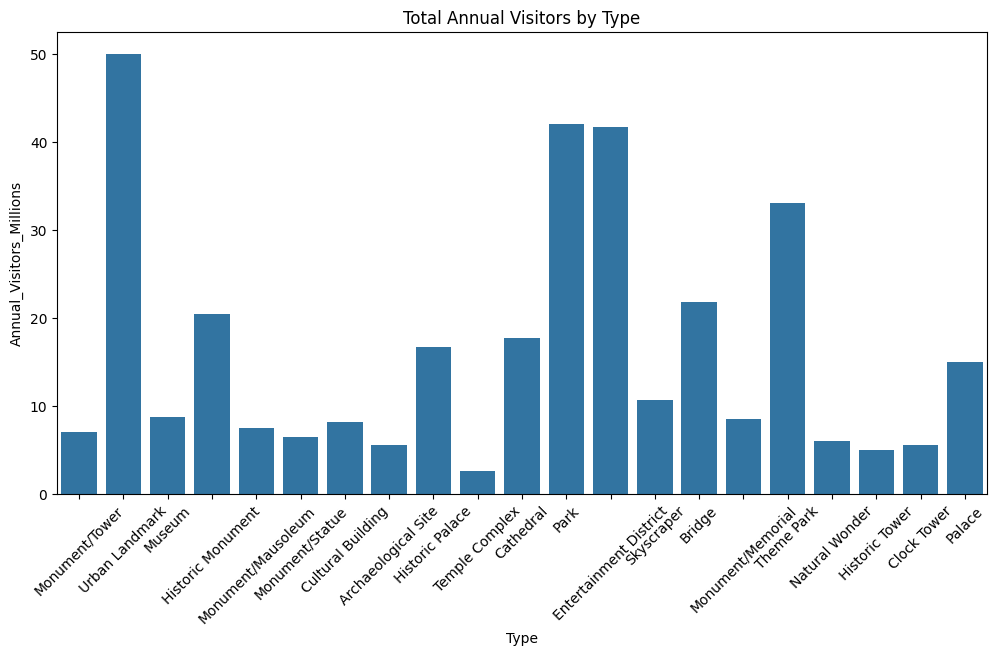

In [16]:
# 4. Relationship Between Features
# -------------------------------
# Annual visitors by Type
plt.figure(figsize=(12,6))
sns.barplot(data=df, x='Type', y='Annual_Visitors_Millions', ci=None, estimator=sum)
plt.title("Total Annual Visitors by Type")
plt.xticks(rotation=45)
plt.show()

##### - Urban landmarks and entertainment-focused attractions attract the highest total visitors.
##### - Traditional monuments and heritage sites show stable but comparatively lower visitor volumes.
<br>

#### Visitors vs Entry Fee

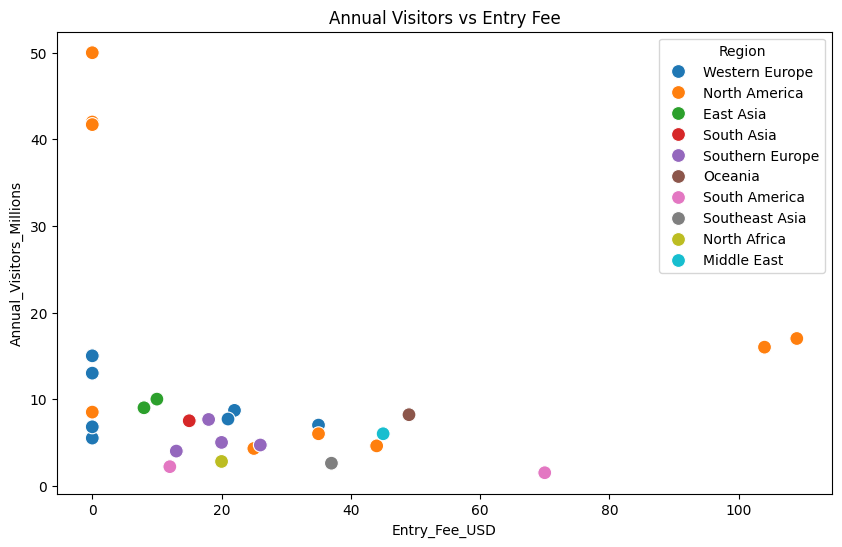

In [24]:
# Visitors vs Entry Fee
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Entry_Fee_USD', y='Annual_Visitors_Millions', hue='Region', s=100)
plt.title("Annual Visitors vs Entry Fee")
plt.show()



##### There is no strong negative relationship between entry fee and visitor count. Many high-fee attractions continue to attract a large number of tourists.
<br>

#### UNESCO vs Non-UNESCO Visitors

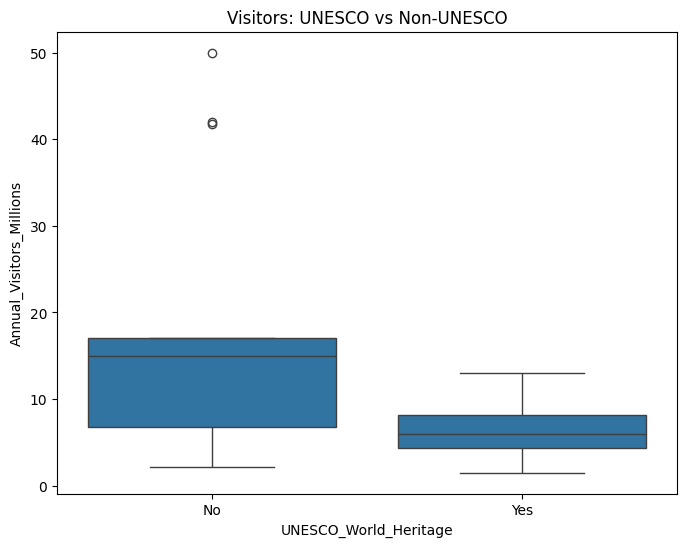

In [25]:
# UNESCO vs Non-UNESCO Sites Visitors
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='UNESCO_World_Heritage', y='Annual_Visitors_Millions')
plt.title("Visitors: UNESCO vs Non-UNESCO")
plt.show()


##### Non-UNESCO sites show higher median visitor counts, mainly due to popular urban landmarks, while UNESCO sites show more consistent visitor numbers.
<br>

#### Top Countries by Annual Visitors

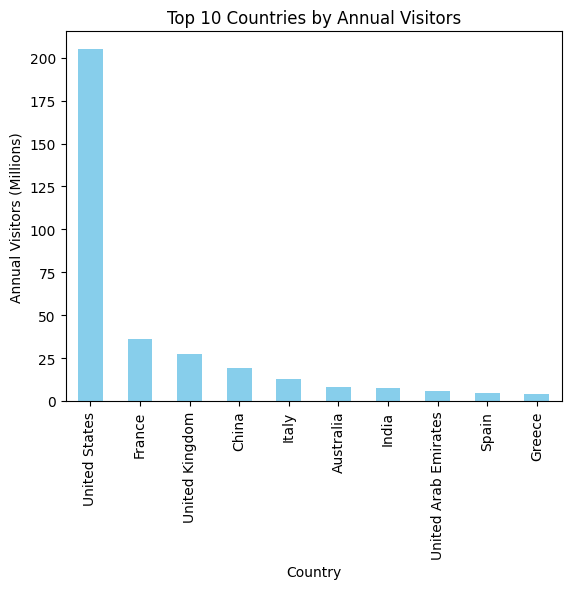

In [27]:
# 5. Top Countries and Cities by Visitors
# -------------------------------
top_countries = df.groupby('Country')['Annual_Visitors_Millions'].sum().sort_values(ascending=False).head(10)
top_countries.plot(kind='bar', color='skyblue', title="Top 10 Countries by Annual Visitors")
plt.ylabel("Annual Visitors (Millions)")
plt.show()

##### The United States leads by a large margin in total annual visitors, followed by France and the United Kingdom.
<br>

#### Top Cities by Annual Visitors

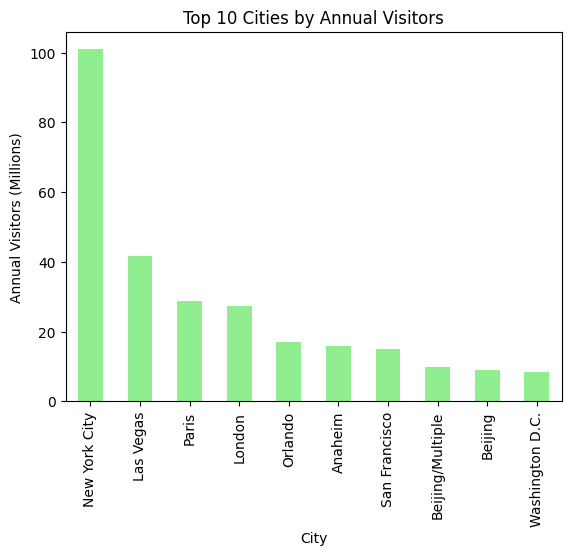

In [28]:
top_cities = df.groupby('City')['Annual_Visitors_Millions'].sum().sort_values(ascending=False).head(10)
top_cities.plot(kind='bar', color='lightgreen', title="Top 10 Cities by Annual Visitors")
plt.ylabel("Annual Visitors (Millions)")
plt.show()


##### - New York City ranks highest due to multiple high-traffic attractions.
##### - Other major cities like Las Vegas, Paris, and London also attract significant tourist volumes.